# Logistic ODE — LC-PINN Sanity Check

**Equation:** $u'(t) = r \, u(t) \left(1 - \frac{u(t)}{K}\right)$

**Parameters:** $r = 2$, $K = 1$, $u_0 = 0.1$, $t \in [0, 2]$.

**Loss terms (3):** ODE residual, IC ($u(0) = 0.1$), sparse noisy data (15 observations, $\sigma = 0.02$).

**Reference:** Exact solution $u(t) = \frac{K \, u_0 \, e^{rt}}{K + u_0(e^{rt} - 1)}$.

**Purpose:** Verify that the LC-PINN framework works on a simple nonlinear ODE before moving to PDEs. This is the easiest benchmark in the ladder — if the method fails here, something is fundamentally broken.

In [2]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import torch
import matplotlib.pyplot as plt
from IPython.display import clear_output

from pinns.model import LossConditionalPINN
from pinns.baseline import FixedWeightPINN, train_fixed_pinn
from pinns.training import train_lc_pinn
from pinns.lambda_sampler import LambdaSampler
from pinns.inference import sweep_lambda
from pinns.device import select_device, device_info

from pinns.equations import logistic as eq

device = select_device()
print(f"Device: {device_info(device)}")
torch.manual_seed(42)
np.random.seed(42)

HIDDEN_DIMS = [64, 64, 64, 64]
N_STEPS = 50_000    # ODE is much easier — 50k is plenty
LR = 1e-3
LOG_EVERY = 2_000

Device: mps (Apple GPU)


/Users/anna/miniconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Reference solution & training data

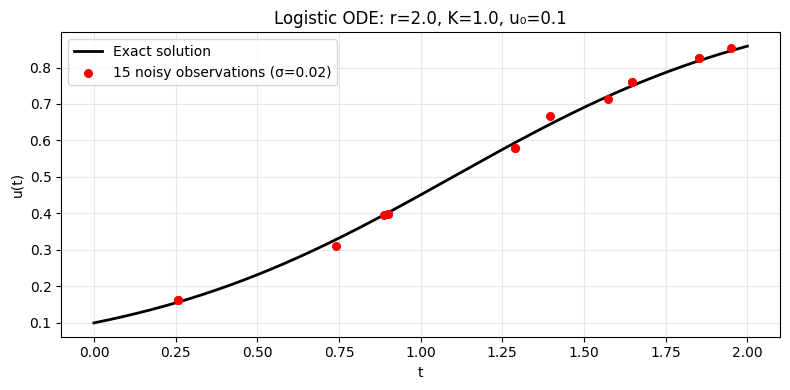

Training data: coords_pde: torch.Size([2000, 1]), coords_ic: torch.Size([200, 1]), u_ic: torch.Size([200, 1]), coords_data: torch.Size([200, 1]), u_data: torch.Size([200, 1])


In [3]:
ref_snapshots = eq.compute_reference_solution()
batch = eq.generate_training_data(device=device)

# Exact solution for plotting
t_plot = np.linspace(0, eq.T_MAX, 500)
u_exact = eq.exact_solution(t_plot)

# Training data points (noisy observations)
t_data = batch["coords_data"].cpu().numpy().flatten()
u_data = batch["u_data"].cpu().numpy().flatten()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_plot, u_exact, 'k-', lw=2, label='Exact solution')
ax.scatter(t_data[:eq.N_OBS], u_data[:eq.N_OBS], c='red', s=30, zorder=5,
           label=f'{eq.N_OBS} noisy observations (σ={eq.OBS_NOISE})')
ax.set_xlabel('t')
ax.set_ylabel('u(t)')
ax.set_title(f'Logistic ODE: r={eq.R}, K={eq.K}, u₀={eq.U0}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Training data: {', '.join(f'{k}: {v.shape}' for k, v in batch.items())}")

## 2. Train LC-PINN

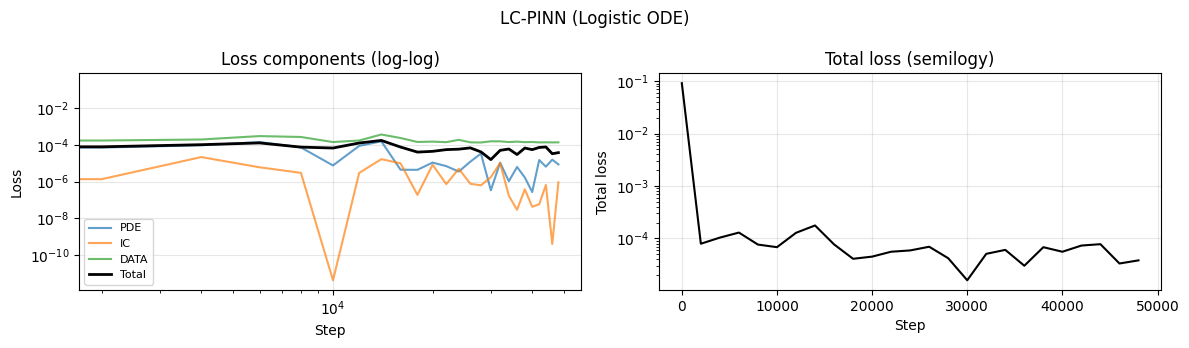

Training: 100%|██████████| 50000/50000 [17:59<00:00, 46.31step/s, L=3.82e-05, hw=3.00]



Training complete in 1080s (18.0 min)
Best log(lambda):     [-2.594  2.753  2.29 ]
Best softmax(lambda): [0.0029 0.6119 0.3852]
Best validation loss: 1.324611e-04

Best lambda (softmax): [0.0029 0.6119 0.3852]
LC-PINN rel-L2: {2.0: 0.006739324920992362}


In [4]:
def make_live_plot_callback(title="Training"):
    def on_log(history):
        clear_output(wait=True)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.5))
        fig.suptitle(title)
        steps = history["step"]
        ax1.set_title("Loss components (log-log)")
        for key in history:
            if key in ("step", "total", "hw", "elapsed_sec"): continue
            ax1.plot(steps, history[key], label=key.upper(), alpha=0.7)
        ax1.plot(steps, history["total"], 'k-', lw=2, label="Total")
        ax1.set_xscale("log"); ax1.set_yscale("log")
        ax1.set_xlabel("Step"); ax1.set_ylabel("Loss")
        ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)
        ax2.set_title("Total loss (semilogy)")
        ax2.semilogy(steps, history["total"], 'k-', lw=1.5)
        ax2.set_xlabel("Step"); ax2.set_ylabel("Total loss"); ax2.grid(True, alpha=0.3)
        fig.tight_layout(); plt.show(); plt.close(fig)
    return on_log

model_lc = LossConditionalPINN(eq.DIM_PHYS, eq.DIM_LAMBDA, HIDDEN_DIMS).to(device)
sampler = LambdaSampler(dim=eq.DIM_LAMBDA, device=device)

history_lc = train_lc_pinn(
    model_lc, sampler, batch, device,
    loss_fn=eq.compute_losses,
    n_epochs=N_STEPS, lr=LR, log_every=LOG_EVERY,
    on_log=make_live_plot_callback("LC-PINN (Logistic ODE)"),
)

# Lambda sweep
best_ll, best_p, _ = sweep_lambda(
    model_lc, batch, sampler, device,
    loss_fn=eq.compute_losses,
    n_candidates=500,
    exclude_terms={"pde"},
)
print(f"\nBest lambda (softmax): {best_p.cpu().numpy().round(4)}")

# Save checkpoint
torch.save({
    "model_state_dict": model_lc.state_dict(),
    "best_log_lambda": best_ll,
    "history": history_lc,
}, "../checkpoints/logistic_lc_pinn.pt")

# Evaluate
lc_errors = eq.evaluate(model_lc, best_ll, ref_snapshots, device)
print(f"LC-PINN rel-L2: {lc_errors}")

## 3. Equal-weight baseline

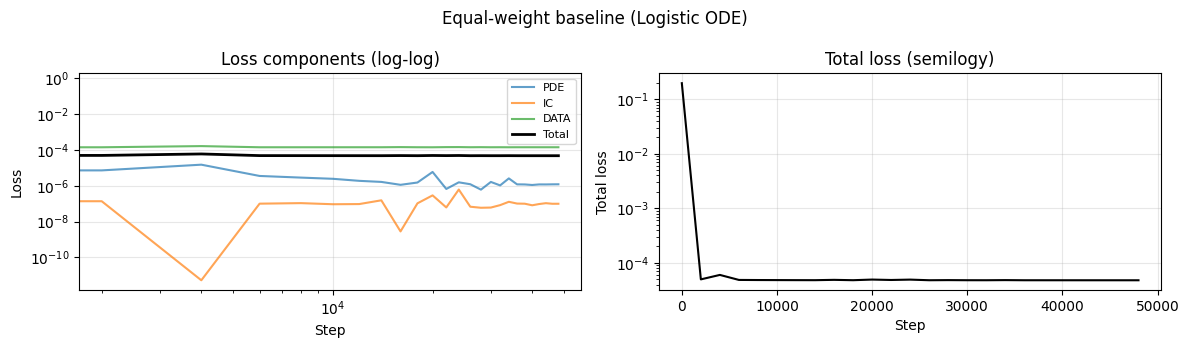

Equal-weight baseline: 100%|██████████| 50000/50000 [04:46<00:00, 174.54step/s, L=4.79e-05]

Equal-weight baseline done in 286s (4.8 min)
Baseline rel-L2: {2.0: 0.0013149870115404005}


In [5]:
equal_weights = [1.0 / eq.DIM_LAMBDA] * eq.DIM_LAMBDA  # [0.333, 0.333, 0.333]
model_baseline = FixedWeightPINN(eq.DIM_PHYS, HIDDEN_DIMS).to(device)

baseline_history = train_fixed_pinn(
    model_baseline, equal_weights, batch, device,
    loss_fn=eq.compute_losses_fixed,
    n_epochs=N_STEPS, lr=LR, log_every=LOG_EVERY,
    desc="Equal-weight baseline",
    on_log=make_live_plot_callback("Equal-weight baseline (Logistic ODE)"),
)

torch.save({"model_state_dict": model_baseline.state_dict()},
           "../checkpoints/logistic_baseline.pt")

baseline_errors = eq.evaluate(model_baseline, None, ref_snapshots, device)
print(f"Baseline rel-L2: {baseline_errors}")

## 4. Comparison

Method                      Rel-L2
----------------------------------------
LC-PINN (best λ)            0.006739
Equal-weight baseline       0.001315


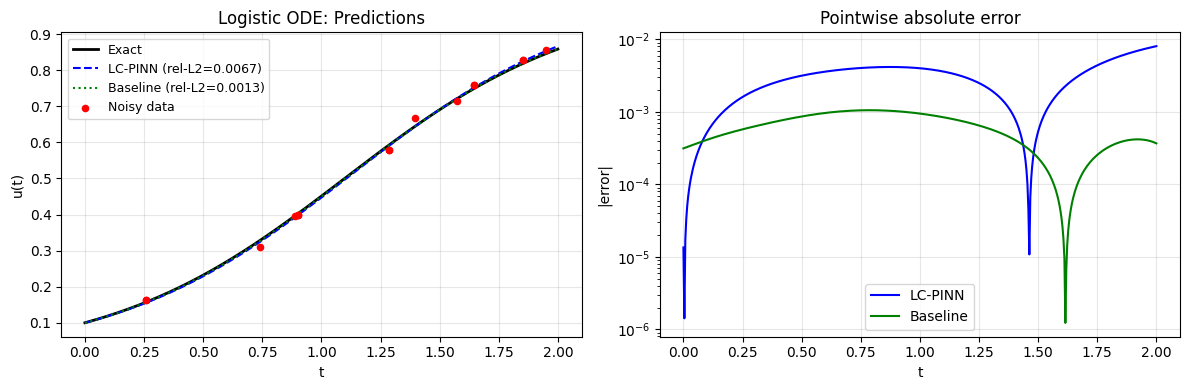

Saved: results/fig_logistic_comparison.png


In [6]:
# --- Comparison table ---
print(f"{'Method':<26}  Rel-L2")
print("-" * 40)
for name, errs in [("LC-PINN (best λ)", lc_errors), ("Equal-weight baseline", baseline_errors)]:
    mean_err = np.mean(list(errs.values()))
    print(f"{name:<26}  {mean_err:.6f}")

# --- Prediction plot ---
t_plot = np.linspace(0, eq.T_MAX, 500)
u_exact = eq.exact_solution(t_plot)
u_lc = eq.predict_solution(model_lc, best_ll, t_plot, 0.0, device)
u_base = eq.predict_solution(model_baseline, None, t_plot, 0.0, device)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: predictions
ax1.plot(t_plot, u_exact, 'k-', lw=2, label='Exact')
ax1.plot(t_plot, u_lc, 'b--', lw=1.5, label=f'LC-PINN (rel-L2={np.mean(list(lc_errors.values())):.4f})')
ax1.plot(t_plot, u_base, 'g:', lw=1.5, label=f'Baseline (rel-L2={np.mean(list(baseline_errors.values())):.4f})')
t_data_np = batch["coords_data"].cpu().numpy().flatten()
u_data_np = batch["u_data"].cpu().numpy().flatten()
ax1.scatter(t_data_np[:eq.N_OBS], u_data_np[:eq.N_OBS], c='red', s=20, zorder=5, label='Noisy data')
ax1.set_xlabel('t'); ax1.set_ylabel('u(t)')
ax1.set_title('Logistic ODE: Predictions')
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

# Right: error
ax2.semilogy(t_plot, np.abs(u_lc - u_exact), 'b-', label='LC-PINN')
ax2.semilogy(t_plot, np.abs(u_base - u_exact), 'g-', label='Baseline')
ax2.set_xlabel('t'); ax2.set_ylabel('|error|')
ax2.set_title('Pointwise absolute error')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/fig_logistic_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../results/fig_logistic_comparison.png")

## 5. Uniform λ sampling ablation

Train a second LC-PINN with `mode="uniform"` — each λ ~ U(0,1), independent, no sum-to-1. Compare to the logspace LC-PINN (section 2) and equal-weight baseline (section 3).

In [ ]:
model_uniform = LossConditionalPINN(eq.DIM_PHYS, eq.DIM_LAMBDA, HIDDEN_DIMS).to(device)
sampler_uniform = LambdaSampler(dim=eq.DIM_LAMBDA, device=device, mode="uniform")

history_uniform = train_lc_pinn(
    model_uniform, sampler_uniform, batch, device,
    loss_fn=eq.compute_losses,
    n_epochs=N_STEPS, lr=LR, log_every=LOG_EVERY,
    on_log=make_live_plot_callback("LC-PINN Uniform (Logistic ODE)"),
)

best_ll_uniform, best_p_uniform, _ = sweep_lambda(
    model_uniform, batch, sampler_uniform, device,
    loss_fn=eq.compute_losses,
    n_candidates=500,
    exclude_terms={"pde"},
)
print(f"\nBest lambda (uniform, raw weights): {best_p_uniform.cpu().numpy().round(4)}")

torch.save({
    "model_state_dict": model_uniform.state_dict(),
    "best_log_lambda": best_ll_uniform,
}, "../checkpoints/logistic_lc_pinn_uniform.pt")

uniform_errors = eq.evaluate(model_uniform, best_ll_uniform, ref_snapshots, device)
print(f"LC-PINN (uniform) rel-L2: {uniform_errors}")
print(f"Mean: {np.mean(list(uniform_errors.values())):.6f}")


## 6. Three-way comparison (baseline · logspace · uniform)

In [ ]:
print(f"{'Method':<28}  Rel-L2")
print("-" * 44)
rows = [
    ("Equal-weight baseline",     baseline_errors),
    ("LC-PINN (logspace, best λ)", lc_errors),
    ("LC-PINN (uniform, best λ)",  uniform_errors),
]
for name, errs in rows:
    mean_err = np.mean(list(errs.values()))
    print(f"{name:<28}  {mean_err:.6f}")

t_plot = np.linspace(0, eq.T_MAX, 500)
u_exact = eq.exact_solution(t_plot)
u_lc = eq.predict_solution(model_lc, best_ll, t_plot, 0.0, device)
u_uniform = eq.predict_solution(model_uniform, best_ll_uniform, t_plot, 0.0, device)
u_base = eq.predict_solution(model_baseline, None, t_plot, 0.0, device)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(t_plot, u_exact, 'k-', lw=2, label='Exact')
ax1.plot(t_plot, u_base,    'g:',  lw=1.5, label=f'Baseline ({np.mean(list(baseline_errors.values())):.4f})')
ax1.plot(t_plot, u_lc,      'b--', lw=1.5, label=f'LC logspace ({np.mean(list(lc_errors.values())):.4f})')
ax1.plot(t_plot, u_uniform, 'r-.', lw=1.5, label=f'LC uniform ({np.mean(list(uniform_errors.values())):.4f})')
ax1.set_xlabel('t'); ax1.set_ylabel('u(t)')
ax1.set_title('Logistic ODE: predictions')
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

ax2.semilogy(t_plot, np.abs(u_base - u_exact),    'g-', label='Baseline')
ax2.semilogy(t_plot, np.abs(u_lc - u_exact),      'b-', label='LC logspace')
ax2.semilogy(t_plot, np.abs(u_uniform - u_exact), 'r-', label='LC uniform')
ax2.set_xlabel('t'); ax2.set_ylabel('|error|')
ax2.set_title('Pointwise absolute error')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/fig_logistic_three_way.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../results/fig_logistic_three_way.png")
